# D5 — SDMX Time Series Analysis

## Objective

In the previous notebooks, we learned how to interact with the BIS SDMX API, navigate SDMX metadata, inspect Data Structure Definitions (DSDs), and manually transform SDMX responses into tabular datasets.

The objective of this notebook is to move beyond data retrieval and begin performing meaningful macroeconomic analysis.

Using the BIS Total Credit dataset, we will:

- Retrieve quarterly macroeconomic data from the BIS SDMX API.
- Convert the SDMX response into an analysis-ready pandas DataFrame.
- Decode SDMX codes into human-readable labels using official codelists.
- Engineer common time-series features such as Quarter-over-Quarter (QoQ) and Year-over-Year (YoY) growth.
- Analyze long-term trends, historical rankings, growth dynamics, and volatility.
- Produce an economic summary similar to the exploratory analysis performed by economists and quantitative analysts working with BIS datasets.

By the end of this notebook, we will have transformed a raw SDMX response into a clean, analysis-ready macroeconomic time series suitable for visualization, statistical analysis, and forecasting.

In [1]:
# ----------------------------------------------------
# Imports
# ----------------------------------------------------

import sdmx
import pandas as pd

In [2]:
# ----------------------------------------------------
# Connect to the BIS SDMX API
# ----------------------------------------------------

client = sdmx.Client("BIS")

print("Connected to:", client.source.id)
print(client.source.url)

Connected to: BIS
https://stats.bis.org/api/v1


In [3]:
# ----------------------------------------------------
# Retrieve the BIS Total Credit Dataflow
# ----------------------------------------------------

flow_response = client.dataflow()

print(type(flow_response))

print(flow_response.dataflow.keys())

<class 'sdmx.message.StructureMessage'>
dict_keys(['BIS_REL_CAL', 'WS_CBPOL', 'WS_CBS_PUB', 'WS_CBTA', 'WS_CPMI_CASHLESS', 'WS_CPMI_CT1', 'WS_CPMI_CT2', 'WS_CPMI_DEVICES', 'WS_CPMI_INSTITUT', 'WS_CPMI_MACRO', 'WS_CPMI_PARTICIP', 'WS_CPMI_SYSTEMS', 'WS_CPP', 'WS_CREDIT_GAP', 'WS_DEBT_SEC2_PUB', 'WS_DER_OTC_TOV', 'WS_DPP', 'WS_DSR', 'WS_EER', 'WS_GLI', 'WS_LBS_D_PUB', 'WS_LONG_CPI', 'WS_NA_SEC_C3', 'WS_NA_SEC_DSS', 'WS_OTC_DERIV2', 'WS_SPP', 'WS_TC', 'WS_XRU', 'WS_XTD_DERIV'])


In [4]:
# ----------------------------------------------------
# Retrieve the Total Credit Dataflow
# ----------------------------------------------------

flow = flow_response.dataflow["WS_TC"]

print("ID   :", flow.id)
print("Name :", flow.name)

ID   : WS_TC
Name : Total credit


In [5]:
# ----------------------------------------------------
# Retrieve the Data Structure Definition (DSD)
# ----------------------------------------------------

dsd = client.get(resource=flow.structure)

print(type(dsd))

<class 'sdmx.message.StructureMessage'>


In [6]:
# ----------------------------------------------------
# Build a Query
# ----------------------------------------------------

query_key = "Q.IN.P.A.M..A"
print(query_key)

Q.IN.P.A.M..A


In [8]:
import inspect

print(inspect.signature(client.data))

(resource_id: str | None = None, tofile: 'os.PathLike | IO | None' = None, use_cache: bool = False, dry_run: bool = False, **kwargs) -> 'sdmx.message.Message | requests.Request'


In [9]:
help(client.data)

Help on partial in module functools:

functools.partial(<bound method Client.get of <s...object at 0x1552deba0>>, <Resource.data: 'data'>)
    Retrieve SDMX data or metadata with resource_type='data'.

    (Meta)data is retrieved from the :attr:`source` of the current Client. The
    item(s) to retrieve can be specified in one of two ways:

    1. `resource_type`, `resource_id`: These give the type (see :class:`Resource`)
       and, optionally, ID of the item(s). If the `resource_id` is not given, all
       items of the given type are retrieved.
    2. a `resource` object, i.e. a :class:`.MaintainableArtefact`: `resource_type`
       and `resource_id` are determined by the object's class and
       :attr:`id <.IdentifiableArtefact.id>` attribute, respectively.

    Data is retrieved with `resource_type='data'`. In this case, the optional
    keyword argument `key` can be used to constrain the data that is retrieved.
    Examples of the formats for `key`:

    1. ``{'GEO': ['EL', 'ES'

In [11]:
# ----------------------------------------------------
# Retrieve Data
# ----------------------------------------------------

# response = client.data(
#     resource=flow,
#     key=query_key
# )

response = client.data(
    resource_id="WS_TC",
    key=query_key
)

dataset = response.data[0]

print(type(dataset))
print("Series       :", len(dataset.series))
print("Observations :", len(dataset.obs))

xml.Reader got no structure=… argument for StructureSpecificData


<class 'sdmx.model.v21.StructureSpecificDataSet'>
Series       : 3
Observations : 874


In [12]:
# ----------------------------------------------------
# Convert the SDMX Dataset to a pandas DataFrame
# ----------------------------------------------------

rows = []

for series_key, observations in dataset.series.items():

    # Series metadata
    metadata = {
        key: value.value
        for key, value in series_key.values.items()
    }

    # Observations
    for obs in observations:

        rows.append({
            **metadata,
            "TIME_PERIOD": obs.dimension.values["TIME_PERIOD"].value,
            "OBS_VALUE": float(obs.value)
        })

df = pd.DataFrame(rows)

df.head()

,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,FREQ,TITLE_TS,UNIT_MULT,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE
0,IN,P,A,M,USD,A,Q,India - Credit to Private non-financial sector...,9,USD,1957-Q1,6.371
1,IN,P,A,M,USD,A,Q,India - Credit to Private non-financial sector...,9,USD,1957-Q2,6.602
2,IN,P,A,M,USD,A,Q,India - Credit to Private non-financial sector...,9,USD,1957-Q3,6.482
3,IN,P,A,M,USD,A,Q,India - Credit to Private non-financial sector...,9,USD,1957-Q4,6.690
4,IN,P,A,M,USD,A,Q,India - Credit to Private non-financial sector...,9,USD,1958-Q1,7.095


In [13]:
# ----------------------------------------------------
# Dataset Overview
# ----------------------------------------------------

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

display(df.head())

df.info()

Rows    : 874
Columns : 12


,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,FREQ,TITLE_TS,UNIT_MULT,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE
0,IN,P,A,M,USD,A,Q,India - Credit to Private non-financial sector...,9,USD,1957-Q1,6.371
1,IN,P,A,M,USD,A,Q,India - Credit to Private non-financial sector...,9,USD,1957-Q2,6.602
2,IN,P,A,M,USD,A,Q,India - Credit to Private non-financial sector...,9,USD,1957-Q3,6.482
3,IN,P,A,M,USD,A,Q,India - Credit to Private non-financial sector...,9,USD,1957-Q4,6.690
4,IN,P,A,M,USD,A,Q,India - Credit to Private non-financial sector...,9,USD,1958-Q1,7.095


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 874 entries, 0 to 873
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BORROWERS_CTY  874 non-null    object 
 1   TC_BORROWERS   874 non-null    object 
 2   TC_LENDERS     874 non-null    object 
 3   VALUATION      874 non-null    object 
 4   UNIT_TYPE      874 non-null    object 
 5   TC_ADJUST      874 non-null    object 
 6   FREQ           874 non-null    object 
 7   TITLE_TS       874 non-null    object 
 8   UNIT_MULT      874 non-null    object 
 9   UNIT_MEASURE   874 non-null    object 
 10  TIME_PERIOD    874 non-null    object 
 11  OBS_VALUE      874 non-null    float64
dtypes: float64(1), object(11)
memory usage: 82.1+ KB


In [14]:
# ----------------------------------------------------
# Data Quality Assessment
# ----------------------------------------------------

summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isna().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
BORROWERS_CTY,object,0,1
TC_BORROWERS,object,0,1
TC_LENDERS,object,0,1
VALUATION,object,0,1
UNIT_TYPE,object,0,3
TC_ADJUST,object,0,1
FREQ,object,0,1
TITLE_TS,object,0,3
UNIT_MULT,object,0,2
UNIT_MEASURE,object,0,3


In [15]:
# ----------------------------------------------------
# Inspect the Time Dimension
# ----------------------------------------------------

print("Frequency :", df["FREQ"].unique())

print("\nSample TIME_PERIOD values:")

display(
    df["TIME_PERIOD"]
      .drop_duplicates()
      .sort_values()
      .head(10)
)

Frequency : ['Q']

Sample TIME_PERIOD values:


276    1951-Q2
277    1951-Q3
278    1951-Q4
279    1952-Q1
280    1952-Q2
281    1952-Q3
282    1952-Q4
283    1953-Q1
284    1953-Q2
285    1953-Q3
Name: TIME_PERIOD, dtype: object

In [16]:
# ----------------------------------------------------
# Convert to pandas Quarterly Period
# ----------------------------------------------------

df["Quarter"] = pd.PeriodIndex(
    df["TIME_PERIOD"],
    freq="Q"
)

df[["TIME_PERIOD", "Quarter"]].head()

,TIME_PERIOD,Quarter
0,1957-Q1,1957Q1
1,1957-Q2,1957Q2
2,1957-Q3,1957Q3
3,1957-Q4,1957Q4
4,1958-Q1,1958Q1


In [17]:
# ----------------------------------------------------
# Convert to pandas Quarterly Period
# ----------------------------------------------------

df["Quarter"] = pd.PeriodIndex(
    df["TIME_PERIOD"],
    freq="Q"
)

df[["TIME_PERIOD", "Quarter"]].head()

,TIME_PERIOD,Quarter
0,1957-Q1,1957Q1
1,1957-Q2,1957Q2
2,1957-Q3,1957Q3
3,1957-Q4,1957Q4
4,1958-Q1,1958Q1


In [18]:
# ----------------------------------------------------
# Create Calendar Features
# ----------------------------------------------------

df["Year"] = df["Quarter"].dt.year
df["Quarter_Number"] = df["Quarter"].dt.quarter

df[
    [
        "TIME_PERIOD",
        "Quarter",
        "Year",
        "Quarter_Number"
    ]
].head()

,TIME_PERIOD,Quarter,Year,Quarter_Number
0,1957-Q1,1957Q1,1957,1
1,1957-Q2,1957Q2,1957,2
2,1957-Q3,1957Q3,1957,3
3,1957-Q4,1957Q4,1957,4
4,1958-Q1,1958Q1,1958,1


In [19]:
# ----------------------------------------------------
# Reorder Columns
# ----------------------------------------------------

column_order = [

    "Year",
    "Quarter",
    "TIME_PERIOD",

    "BORROWERS_CTY",
    "TC_BORROWERS",
    "TC_LENDERS",

    "VALUATION",
    "UNIT_TYPE",
    "TC_ADJUST",

    "OBS_VALUE"
]

df = df[column_order]

df.head()

,Year,Quarter,TIME_PERIOD,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,OBS_VALUE
0,1957,1957Q1,1957-Q1,IN,P,A,M,USD,A,6.371
1,1957,1957Q2,1957-Q2,IN,P,A,M,USD,A,6.602
2,1957,1957Q3,1957-Q3,IN,P,A,M,USD,A,6.482
3,1957,1957Q4,1957-Q4,IN,P,A,M,USD,A,6.690
4,1958,1958Q1,1958-Q1,IN,P,A,M,USD,A,7.095


In [20]:
# ----------------------------------------------------
# Dataset Summary
# ----------------------------------------------------

summary = pd.DataFrame({

    "Metric": [

        "Observations",
        "Countries",
        "Borrower Sectors",
        "Lender Sectors",
        "Units",
        "Years Covered"

    ],

    "Value": [

        len(df),

        df["BORROWERS_CTY"].nunique(),

        df["TC_BORROWERS"].nunique(),

        df["TC_LENDERS"].nunique(),

        df["UNIT_TYPE"].nunique(),

        f"{df['Year'].min()} - {df['Year'].max()}"

    ]
})

summary

,Metric,Value
0,Observations,874
1,Countries,1
2,Borrower Sectors,1
3,Lender Sectors,1
4,Units,3
5,Years Covered,1951 - 2025


In [21]:
# ----------------------------------------------------
# Retrieve the Data Structure Definition (DSD)
# ----------------------------------------------------

dsd = client.get(resource=flow.structure)

print(type(dsd))

<class 'sdmx.message.StructureMessage'>


In [26]:
# ----------------------------------------------------
# Available Codelists
# ----------------------------------------------------

df_codelists = pd.DataFrame({
    "Codelist ID": list(codelists.keys()),
    "Name": [str(cl.name) for cl in codelists.values()]
})

df_codelists

,Codelist ID,Name
0,CL_ADJUST,Adjustment codelist
1,CL_AREA,Reference area code list
2,CL_BIS_UNIT,BIS_Unit
3,CL_COLLECTION,Collection
4,CL_CONF_STATUS,Observation confidentiality code list
5,CL_DECIMALS,"Decimals codelist (BIS, ECB)"
6,CL_FREQ,Code list for Frequency (FREQ)
7,CL_OBS_STATUS,"Observation status codelist (BIS, ECB, Eurosta..."
8,CL_SUB_CHANNEL,Submission channel
9,P,


In [27]:
# ----------------------------------------------------
# Build a Code Lookup Dictionary
# ----------------------------------------------------

def codelist_to_dict(codelist):

    return {
        code.id: str(code.name)
        for code in codelist.items.values()
    }

In [29]:
# ----------------------------------------------------
# Create Lookup Dictionaries
# ----------------------------------------------------

country_lookup = codelist_to_dict(
    codelists["CL_AREA"]
)

borrower_lookup = codelist_to_dict(
    codelists["CL_TC_BORROWERS"]
)

lender_lookup = codelist_to_dict(
    codelists["CL_TC_LENDERS"]
)

valuation_lookup = codelist_to_dict(
    codelists["CL_VALUATION"]
)

adjust_lookup = codelist_to_dict(
    codelists["CL_ADJUST"]
)

frequency_lookup = codelist_to_dict(
    codelists["CL_FREQ"]
)

In [31]:
# ----------------------------------------------------
# Inspect Available Data Structures
# ----------------------------------------------------

print(type(dsd.structure))
print()

for key in dsd.structure.keys():
    print(key)

<class 'sdmx.dictlike.DictLike'>

BIS_TOTAL_CREDIT


In [32]:
# ----------------------------------------------------
# Retrieve the Data Structure Definition
# ----------------------------------------------------

structure = next(iter(dsd.structure.values()))

print(structure.id)

BIS_TOTAL_CREDIT


In [33]:
# ----------------------------------------------------
# Dimension → Codelist Mapping
# ----------------------------------------------------

mapping = []

for dim in structure.dimensions:

    rep = dim.local_representation

    codelist = None

    if rep is not None and rep.enumerated is not None:
        codelist = rep.enumerated.id

    mapping.append({
        "Dimension": dim.id,
        "Dimension Name": str(dim.concept_identity.name),
        "Codelist": codelist
    })

pd.DataFrame(mapping)

,Dimension,Dimension Name,Codelist
0,FREQ,Frequency,CL_FREQ
1,BORROWERS_CTY,Borrowers' country,CL_AREA
2,TC_BORROWERS,Borrowing sector,CL_TC_BORROWERS
3,TC_LENDERS,Lending sector,CL_TC_LENDERS
4,VALUATION,Valuation method,CL_VALUATION
5,UNIT_TYPE,Unit type,CL_BIS_UNIT
6,TC_ADJUST,Adjustment,CL_ADJUST
7,TIME_PERIOD,Time period or range,None


In [34]:
# ----------------------------------------------------
# Build Lookup Dictionaries
# ----------------------------------------------------

def codelist_to_dict(codelist):
    return {
        code.id: str(code.name)
        for code in codelist.items.values()
    }

lookup_tables = {
    "BORROWERS_CTY": codelist_to_dict(codelists["CL_AREA"]),
    "TC_BORROWERS": codelist_to_dict(codelists["CL_TC_BORROWERS"]),
    "TC_LENDERS": codelist_to_dict(codelists["CL_TC_LENDERS"]),
    "VALUATION": codelist_to_dict(codelists["CL_VALUATION"]),
    "UNIT_TYPE": codelist_to_dict(codelists["CL_BIS_UNIT"]),
    "TC_ADJUST": codelist_to_dict(codelists["CL_ADJUST"]),
    "FREQ": codelist_to_dict(codelists["CL_FREQ"])
}

In [36]:
# ----------------------------------------------------
# Decode SDMX Codes
# ----------------------------------------------------

df_analysis = df.copy()

for column, lookup in lookup_tables.items():

    if column in df_analysis.columns:

        df_analysis[f"{column}_LABEL"] = (
            df_analysis[column]
            .map(lookup)
        )

df_analysis.head()

,Year,Quarter,TIME_PERIOD,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,OBS_VALUE,BORROWERS_CTY_LABEL,TC_BORROWERS_LABEL,TC_LENDERS_LABEL,VALUATION_LABEL,UNIT_TYPE_LABEL,TC_ADJUST_LABEL
0,1957,1957Q1,1957-Q1,IN,P,A,M,USD,A,6.371,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
1,1957,1957Q2,1957-Q2,IN,P,A,M,USD,A,6.602,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
2,1957,1957Q3,1957-Q3,IN,P,A,M,USD,A,6.482,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
3,1957,1957Q4,1957-Q4,IN,P,A,M,USD,A,6.690,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
4,1958,1958Q1,1958-Q1,IN,P,A,M,USD,A,7.095,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks


In [38]:
lookup_tables = {
    "BORROWERS_CTY": codelist_to_dict(codelists["CL_AREA"]),
    "TC_BORROWERS": codelist_to_dict(codelists["CL_TC_BORROWERS"]),
    "TC_LENDERS": codelist_to_dict(codelists["CL_TC_LENDERS"]),
    "VALUATION": codelist_to_dict(codelists["CL_VALUATION"]),
    "UNIT_TYPE": codelist_to_dict(codelists["CL_BIS_UNIT"]),
    "TC_ADJUST": codelist_to_dict(codelists["CL_ADJUST"])
}

In [39]:
# ----------------------------------------------------
# Analysis-Ready Dataset
# ----------------------------------------------------

print(f"Rows    : {len(df_analysis):,}")
print(f"Columns : {df_analysis.shape[1]}")

display(df_analysis.head(10))

Rows    : 874
Columns : 16


,Year,Quarter,TIME_PERIOD,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,OBS_VALUE,BORROWERS_CTY_LABEL,TC_BORROWERS_LABEL,TC_LENDERS_LABEL,VALUATION_LABEL,UNIT_TYPE_LABEL,TC_ADJUST_LABEL
0,1957,1957Q1,1957-Q1,IN,P,A,M,USD,A,6.371,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
1,1957,1957Q2,1957-Q2,IN,P,A,M,USD,A,6.602,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
2,1957,1957Q3,1957-Q3,IN,P,A,M,USD,A,6.482,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
3,1957,1957Q4,1957-Q4,IN,P,A,M,USD,A,6.690,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
4,1958,1958Q1,1958-Q1,IN,P,A,M,USD,A,7.095,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
5,1958,1958Q2,1958-Q2,IN,P,A,M,USD,A,7.120,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
6,1958,1958Q3,1958-Q3,IN,P,A,M,USD,A,7.103,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
7,1958,1958Q4,1958-Q4,IN,P,A,M,USD,A,7.327,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
8,1959,1959Q1,1959-Q1,IN,P,A,M,USD,A,7.791,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
9,1959,1959Q2,1959-Q2,IN,P,A,M,USD,A,8.028,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks


In [40]:
df_analysis.to_csv('../output/bis_total_credit_analysis_ready.csv')

In [41]:
df_analysis["UNIT_TYPE_LABEL"].value_counts()

UNIT_TYPE_LABEL
Domestic currency (incl. conv. to current ccy made using a fix parity)    299
Percentage of GDP                                                         299
US dollar                                                                 276
Name: count, dtype: int64

In [42]:
df_analysis["TC_ADJUST_LABEL"].value_counts()

TC_ADJUST_LABEL
Adjusted for breaks    874
Name: count, dtype: int64

In [43]:
df_analysis["VALUATION_LABEL"].value_counts()

VALUATION_LABEL
Market value    874
Name: count, dtype: int64

In [44]:
# ----------------------------------------------------
# Identify the Available Time Series
# ----------------------------------------------------

series_columns = [
    "UNIT_TYPE_LABEL",
    "TC_ADJUST_LABEL"
]

series_summary = (
    df_analysis
    .groupby(series_columns)
    .agg(
        Observations=("OBS_VALUE", "count"),
        Start=("TIME_PERIOD", "min"),
        End=("TIME_PERIOD", "max")
    )
    .reset_index()
)

series_summary

,UNIT_TYPE_LABEL,TC_ADJUST_LABEL,Observations,Start,End
0,Domestic currency (incl. conv. to current ccy ...,Adjusted for breaks,299,1951-Q2,2025-Q4
1,Percentage of GDP,Adjusted for breaks,299,1951-Q2,2025-Q4
2,US dollar,Adjusted for breaks,276,1957-Q1,2025-Q4


In [45]:
 # ----------------------------------------------------
# Split into Individual Time Series
# ----------------------------------------------------

df_usd = df_analysis[
    (df_analysis["UNIT_TYPE_LABEL"] == "US dollar")
]

df_inr = df_analysis[
    (df_analysis["UNIT_TYPE_LABEL"] == "Domestic currency") &
    (df_analysis["TC_ADJUST_LABEL"] == "Adjusted for breaks")
]

df_gdp = df_analysis[
    (df_analysis["UNIT_TYPE_LABEL"] == "Percentage of GDP")
]

df_inr_unadj = df_analysis[
    (df_analysis["UNIT_TYPE_LABEL"] == "Domestic currency") &
    (df_analysis["TC_ADJUST_LABEL"] == "Unadjusted")
]

In [46]:
df_analysis["UNIT_TYPE_LABEL"].unique()

array(['US dollar',
       'Domestic currency (incl. conv. to current ccy made using a fix parity)',
       'Percentage of GDP'], dtype=object)

In [47]:
df_analysis["TC_ADJUST_LABEL"].unique()

array(['Adjusted for breaks'], dtype=object)

In [48]:
# ----------------------------------------------------
# Verify Each Time Series
# ----------------------------------------------------

summary = pd.DataFrame({
    "Series": [
        "USD",
        "Domestic Currency (Adjusted)",
        "Credit to GDP",
        "Domestic Currency (Unadjusted)"
    ],
    "Rows": [
        len(df_usd),
        len(df_inr),
        len(df_gdp),
        len(df_inr_unadj)
    ]
})

summary

,Series,Rows
0,USD,276
1,Domestic Currency (Adjusted),0
2,Credit to GDP,299
3,Domestic Currency (Unadjusted),0


In [49]:
# ----------------------------------------------------
# Inspect Available Unit Types
# ----------------------------------------------------

df_analysis["UNIT_TYPE_LABEL"].value_counts()

UNIT_TYPE_LABEL
Domestic currency (incl. conv. to current ccy made using a fix parity)    299
Percentage of GDP                                                         299
US dollar                                                                 276
Name: count, dtype: int64

In [50]:
# ----------------------------------------------------
# Inspect Available Adjustment Types
# ----------------------------------------------------

df_analysis["TC_ADJUST_LABEL"].value_counts()

TC_ADJUST_LABEL
Adjusted for breaks    874
Name: count, dtype: int64

In [51]:
# ----------------------------------------------------
# Split the Dataset into Individual Time Series
# ----------------------------------------------------

series_dfs = {}

for unit in df_analysis["UNIT_TYPE_LABEL"].unique():

    df_series = (
        df_analysis[df_analysis["UNIT_TYPE_LABEL"] == unit]
        .sort_values("Quarter")
        .reset_index(drop=True)
    )

    series_dfs[unit] = df_series

print("Available Series:\n")

for name, data in series_dfs.items():
    print(f"{name:<70} {len(data)} observations")

Available Series:

US dollar                                                              276 observations
Domestic currency (incl. conv. to current ccy made using a fix parity) 299 observations
Percentage of GDP                                                      299 observations


In [52]:
# ----------------------------------------------------
# Summary of Each Time Series
# ----------------------------------------------------

summary = []

for name, data in series_dfs.items():

    summary.append({

        "Series": name,

        "Observations": len(data),

        "Start": data["TIME_PERIOD"].min(),

        "End": data["TIME_PERIOD"].max(),

        "Minimum": data["OBS_VALUE"].min(),

        "Maximum": data["OBS_VALUE"].max()

    })

pd.DataFrame(summary)

,Series,Observations,Start,End,Minimum,Maximum
0,US dollar,276,1957-Q1,2025-Q4,6.371,3849.038
1,Domestic currency (incl. conv. to current ccy ...,299,1951-Q2,2025-Q4,22.052,345910.779
2,Percentage of GDP,299,1951-Q2,2025-Q4,21.300,114.800


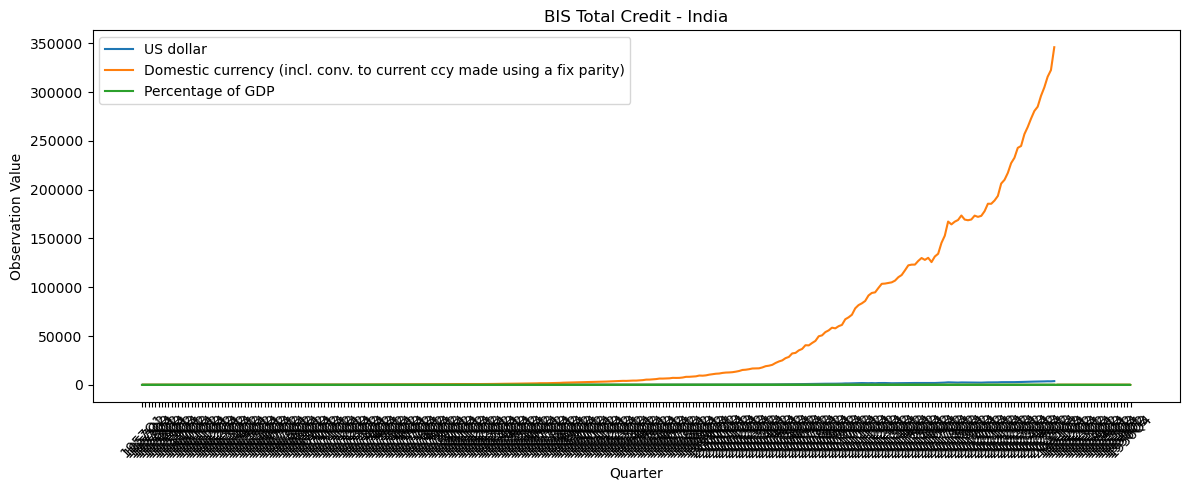

In [53]:
# ----------------------------------------------------
# Plot Each Time Series
# ----------------------------------------------------

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

for name, data in series_dfs.items():

    ax.plot(
        data["Quarter"].astype(str),
        data["OBS_VALUE"],
        label=name
    )

ax.set_title("BIS Total Credit - India")
ax.set_xlabel("Quarter")
ax.set_ylabel("Observation Value")

ax.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [55]:
# ----------------------------------------------------
# Inspect Data Types
# ----------------------------------------------------

for name, data in series_dfs.items():

    print("=" * 80)
    print(name)
    print(data.dtypes)
    print()

US dollar
Year                           int64
Quarter                period[Q-DEC]
TIME_PERIOD                   object
BORROWERS_CTY                 object
TC_BORROWERS                  object
TC_LENDERS                    object
VALUATION                     object
UNIT_TYPE                     object
TC_ADJUST                     object
OBS_VALUE                    float64
BORROWERS_CTY_LABEL           object
TC_BORROWERS_LABEL            object
TC_LENDERS_LABEL              object
VALUATION_LABEL               object
UNIT_TYPE_LABEL               object
TC_ADJUST_LABEL               object
dtype: object

Domestic currency (incl. conv. to current ccy made using a fix parity)
Year                           int64
Quarter                period[Q-DEC]
TIME_PERIOD                   object
BORROWERS_CTY                 object
TC_BORROWERS                  object
TC_LENDERS                    object
VALUATION                     object
UNIT_TYPE                     object
TC_ADJUST       

In [56]:
# ----------------------------------------------------
# Inspect Sample Data
# ----------------------------------------------------

for name, data in series_dfs.items():

    print("=" * 80)
    print(name)

    display(data.head())

    break

US dollar


,Year,Quarter,TIME_PERIOD,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,OBS_VALUE,BORROWERS_CTY_LABEL,TC_BORROWERS_LABEL,TC_LENDERS_LABEL,VALUATION_LABEL,UNIT_TYPE_LABEL,TC_ADJUST_LABEL
0,1957,1957Q1,1957-Q1,IN,P,A,M,USD,A,6.371,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
1,1957,1957Q2,1957-Q2,IN,P,A,M,USD,A,6.602,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
2,1957,1957Q3,1957-Q3,IN,P,A,M,USD,A,6.482,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
3,1957,1957Q4,1957-Q4,IN,P,A,M,USD,A,6.690,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks
4,1958,1958Q1,1958-Q1,IN,P,A,M,USD,A,7.095,India,Private non-financial sector,All sectors,Market value,US dollar,Adjusted for breaks


In [57]:
for data in series_dfs.values():
    data["OBS_VALUE"] = pd.to_numeric(data["OBS_VALUE"])

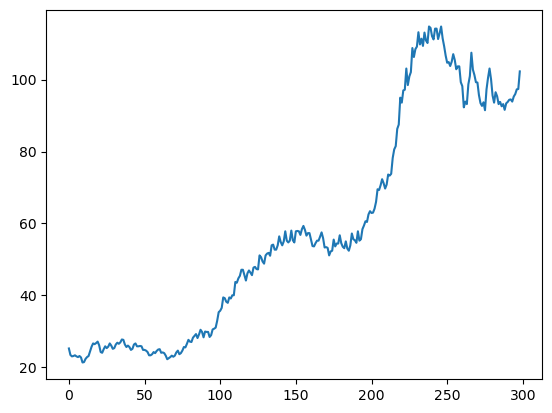

In [58]:
plt.plot(
    data.index,
    data["OBS_VALUE"]
)

In [60]:
# ----------------------------------------------------
# Create a Quarterly Date Column
# ----------------------------------------------------

df_analysis["Date"] = (
    df_analysis["Quarter"]
    .dt.to_timestamp()
)

df_analysis[["TIME_PERIOD", "Quarter", "Date"]].head()

,TIME_PERIOD,Quarter,Date
0,1957-Q1,1957Q1,1957-01-01
1,1957-Q2,1957Q2,1957-04-01
2,1957-Q3,1957Q3,1957-07-01
3,1957-Q4,1957Q4,1957-10-01
4,1958-Q1,1958Q1,1958-01-01


In [61]:
# ----------------------------------------------------
# Rebuild Individual Time Series
# ----------------------------------------------------

series_dfs = {}

for unit in df_analysis["UNIT_TYPE_LABEL"].unique():

    series_dfs[unit] = (
        df_analysis[df_analysis["UNIT_TYPE_LABEL"] == unit]
        .sort_values("Date")
        .reset_index(drop=True)
    )

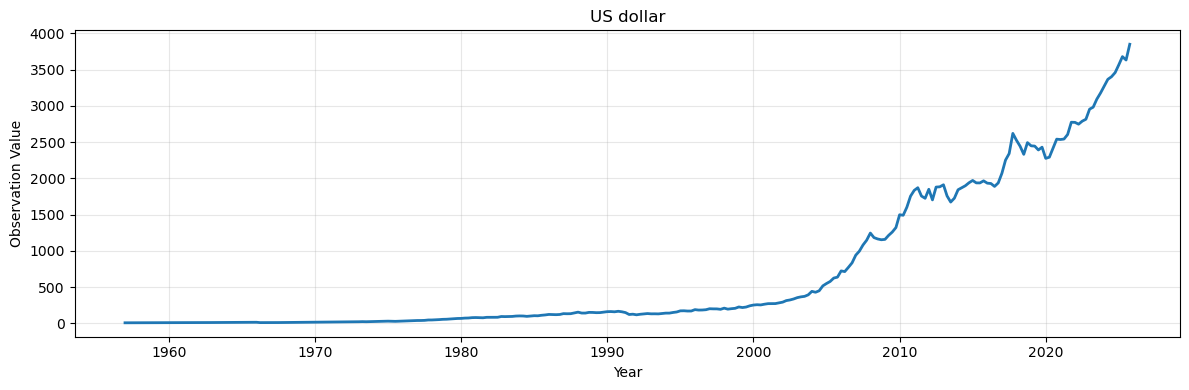

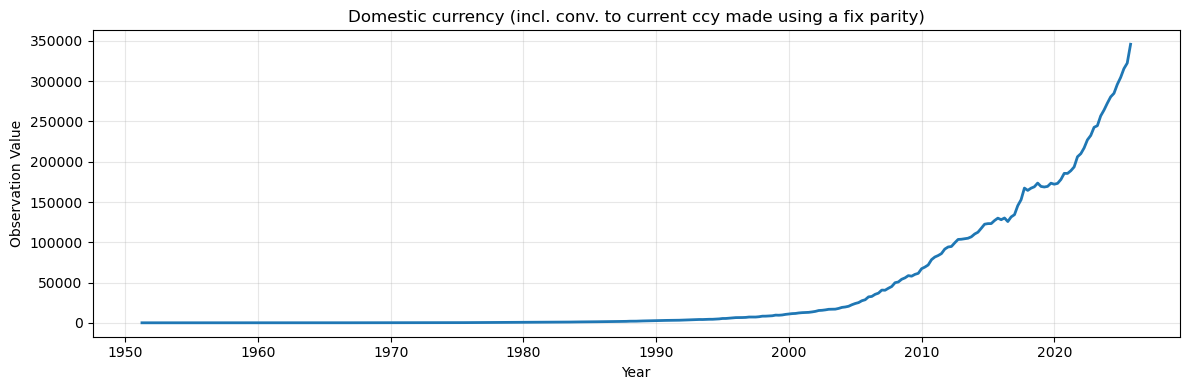

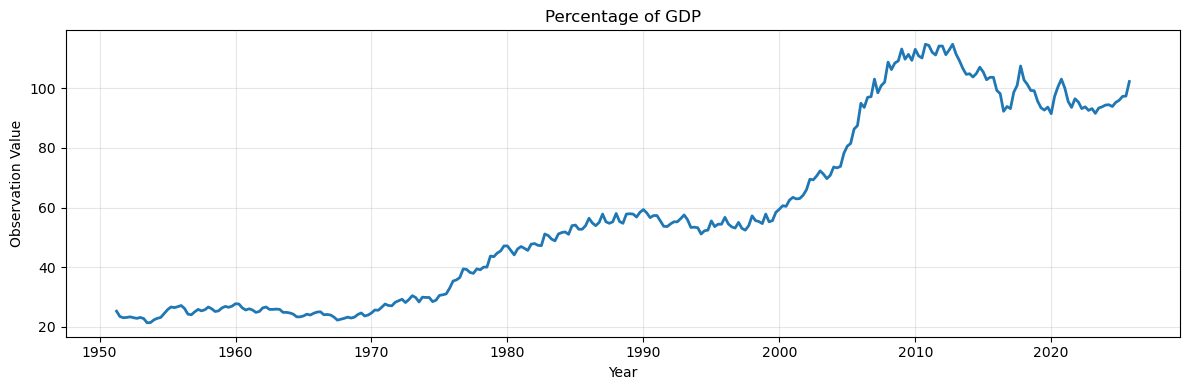

In [62]:
# ----------------------------------------------------
# Plot Each Time Series
# ----------------------------------------------------

import matplotlib.pyplot as plt

for name, data in series_dfs.items():

    plt.figure(figsize=(12,4))

    plt.plot(
        data["Date"],
        data["OBS_VALUE"],
        linewidth=2
    )

    plt.title(name)
    plt.xlabel("Year")
    plt.ylabel("Observation Value")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

In [63]:
# ----------------------------------------------------
# Calculate Quarter-over-Quarter Growth
# ----------------------------------------------------

for name, data in series_dfs.items():

    data["QoQ_Growth (%)"] = (
        data["OBS_VALUE"]
        .pct_change()
        .mul(100)
    )

print("QoQ growth calculated for all series.")

QoQ growth calculated for all series.


In [64]:
# ----------------------------------------------------
# Calculate Year-over-Year Growth
# ----------------------------------------------------

for name, data in series_dfs.items():

    data["YoY_Growth (%)"] = (
        data["OBS_VALUE"]
        .pct_change(4)
        .mul(100)
    )

print("YoY growth calculated for all series.")

YoY growth calculated for all series.


In [65]:
# ----------------------------------------------------
# Inspect the Domestic Currency Series
# ----------------------------------------------------

series_dfs[
    "Domestic currency (incl. conv. to current ccy made using a fix parity)"
].head(10)

,Year,Quarter,TIME_PERIOD,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,OBS_VALUE,BORROWERS_CTY_LABEL,TC_BORROWERS_LABEL,TC_LENDERS_LABEL,VALUATION_LABEL,UNIT_TYPE_LABEL,TC_ADJUST_LABEL,Date,QoQ_Growth (%),YoY_Growth (%)
0,1951,1951Q2,1951-Q2,IN,P,A,M,XDC,A,24.279,India,Private non-financial sector,All sectors,Market value,Domestic currency (incl. conv. to current ccy ...,Adjusted for breaks,1951-04-01,NaN,NaN
1,1951,1951Q3,1951-Q3,IN,P,A,M,XDC,A,22.894,India,Private non-financial sector,All sectors,Market value,Domestic currency (incl. conv. to current ccy ...,Adjusted for breaks,1951-07-01,-5.704518,NaN
2,1951,1951Q4,1951-Q4,IN,P,A,M,XDC,A,22.638,India,Private non-financial sector,All sectors,Market value,Domestic currency (incl. conv. to current ccy ...,Adjusted for breaks,1951-10-01,-1.118197,NaN
3,1952,1952Q1,1952-Q1,IN,P,A,M,XDC,A,22.777,India,Private non-financial sector,All sectors,Market value,Domestic currency (incl. conv. to current ccy ...,Adjusted for breaks,1952-01-01,0.614012,NaN
4,1952,1952Q2,1952-Q2,IN,P,A,M,XDC,A,22.670,India,Private non-financial sector,All sectors,Market value,Domestic currency (incl. conv. to current ccy ...,Adjusted for breaks,1952-04-01,-0.469772,-6.627126
5,1952,1952Q3,1952-Q3,IN,P,A,M,XDC,A,22.127,India,Private non-financial sector,All sectors,Market value,Domestic currency (incl. conv. to current ccy ...,Adjusted for breaks,1952-07-01,-2.395236,-3.350223
6,1952,1952Q4,1952-Q4,IN,P,A,M,XDC,A,22.052,India,Private non-financial sector,All sectors,Market value,Domestic currency (incl. conv. to current ccy ...,Adjusted for breaks,1952-10-01,-0.338952,-2.588568
7,1953,1953Q1,1953-Q1,IN,P,A,M,XDC,A,22.606,India,Private non-financial sector,All sectors,Market value,Domestic currency (incl. conv. to current ccy ...,Adjusted for breaks,1953-01-01,2.512244,-0.750757
8,1953,1953Q2,1953-Q2,IN,P,A,M,XDC,A,22.894,India,Private non-financial sector,All sectors,Market value,Domestic currency (incl. conv. to current ccy ...,Adjusted for breaks,1953-04-01,1.273998,0.988090
9,1953,1953Q3,1953-Q3,IN,P,A,M,XDC,A,22.116,India,Private non-financial sector,All sectors,Market value,Domestic currency (incl. conv. to current ccy ...,Adjusted for breaks,1953-07-01,-3.398270,-0.049713


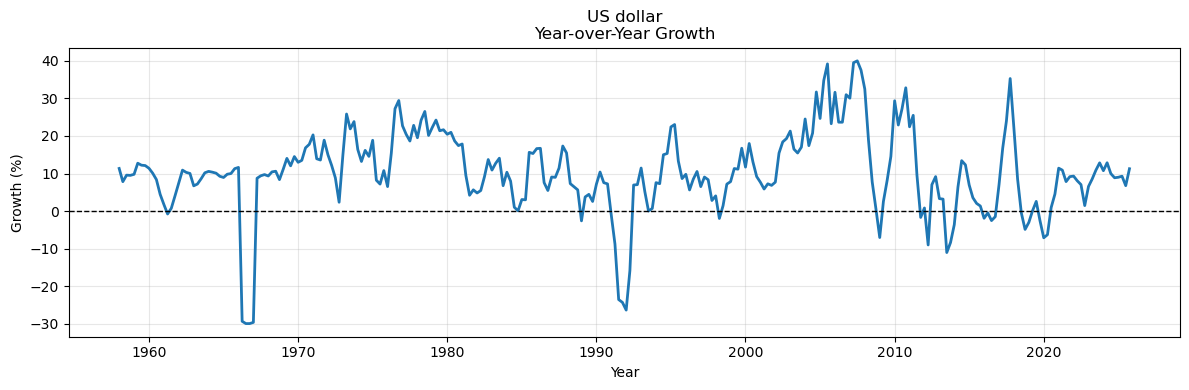

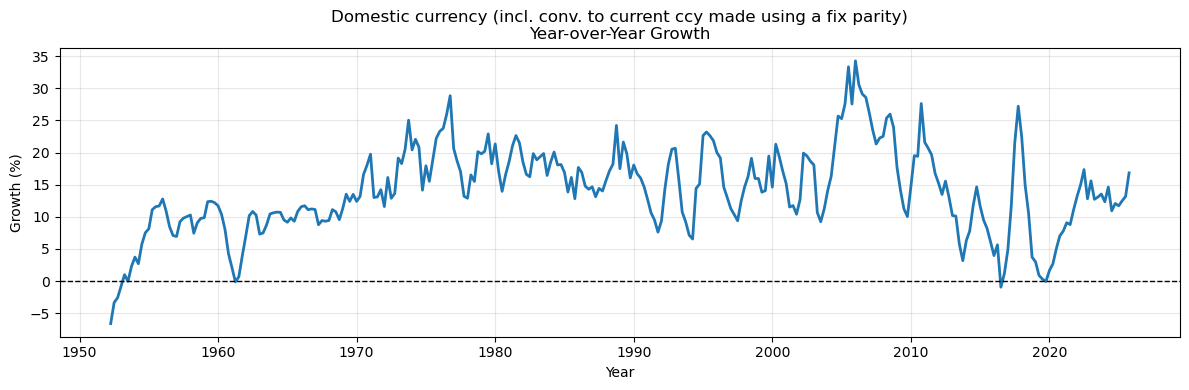

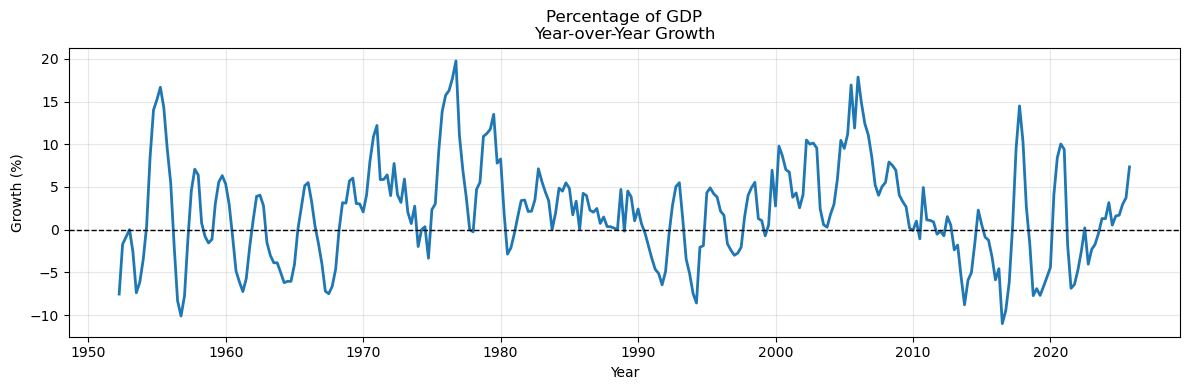

In [66]:
# ----------------------------------------------------
# Plot Year-over-Year Growth
# ----------------------------------------------------

import matplotlib.pyplot as plt

for name, data in series_dfs.items():

    plt.figure(figsize=(12, 4))

    plt.plot(
        data["Date"],
        data["YoY_Growth (%)"],
        linewidth=2
    )

    plt.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    plt.title(f"{name}\nYear-over-Year Growth")
    plt.xlabel("Year")
    plt.ylabel("Growth (%)")

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [67]:
# ----------------------------------------------------
# Select the Credit-to-GDP Series
# ----------------------------------------------------

df_credit_gdp = series_dfs["Percentage of GDP"].copy()

print(df_credit_gdp.shape)

df_credit_gdp.head()

(299, 19)


,Year,Quarter,TIME_PERIOD,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,OBS_VALUE,BORROWERS_CTY_LABEL,TC_BORROWERS_LABEL,TC_LENDERS_LABEL,VALUATION_LABEL,UNIT_TYPE_LABEL,TC_ADJUST_LABEL,Date,QoQ_Growth (%),YoY_Growth (%)
0,1951,1951Q2,1951-Q2,IN,P,A,M,770,A,25.2,India,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1951-04-01,NaN,NaN
1,1951,1951Q3,1951-Q3,IN,P,A,M,770,A,23.4,India,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1951-07-01,-7.142857,NaN
2,1951,1951Q4,1951-Q4,IN,P,A,M,770,A,23.0,India,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1951-10-01,-1.709402,NaN
3,1952,1952Q1,1952-Q1,IN,P,A,M,770,A,23.1,India,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1952-01-01,0.434783,NaN
4,1952,1952Q2,1952-Q2,IN,P,A,M,770,A,23.3,India,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1952-04-01,0.865801,-7.539683


In [68]:
# ----------------------------------------------------
# Largest Quarterly Increases
# ----------------------------------------------------

(
    df_credit_gdp
    .nlargest(
        10,
        "QoQ_Growth (%)"
    )[
        [
            "TIME_PERIOD",
            "OBS_VALUE",
            "QoQ_Growth (%)"
        ]
    ]
)

,TIME_PERIOD,OBS_VALUE,QoQ_Growth (%)
110,1978-Q4,43.7,9.250000
219,2006-Q1,95.0,8.571429
126,1982-Q4,51.1,8.262712
102,1976-Q4,39.4,7.945205
99,1976-Q1,35.3,7.294833
227,2008-Q1,108.8,6.562194
266,2017-Q4,107.5,6.435644
276,2020-Q2,97.3,6.338798
98,1975-Q4,32.9,6.129032
187,1998-Q1,57.2,6.122449


In [69]:
# ----------------------------------------------------
# Largest Quarterly Declines
# ----------------------------------------------------

(
    df_credit_gdp
    .nsmallest(
        10,
        "QoQ_Growth (%)"
    )[
        [
            "TIME_PERIOD",
            "OBS_VALUE",
            "QoQ_Growth (%)"
        ]
    ]
)

,TIME_PERIOD,OBS_VALUE,QoQ_Growth (%)
21,1956-Q3,24.2,-7.279693
1,1951-Q3,23.4,-7.142857
9,1953-Q3,21.3,-6.167401
261,2016-Q3,92.3,-6.008147
89,1973-Q3,28.3,-5.033557
37,1960-Q3,26.3,-4.710145
93,1974-Q3,28.4,-4.697987
148,1988-Q2,55.3,-4.655172
169,1993-Q3,53.3,-4.651163
144,1987-Q2,55.2,-4.498270


In [70]:
# ----------------------------------------------------
# Largest Year-over-Year Growth
# ----------------------------------------------------

(
    df_credit_gdp
    .nlargest(
        10,
        "YoY_Growth (%)"
    )[
        [
            "TIME_PERIOD",
            "OBS_VALUE",
            "YoY_Growth (%)"
        ]
    ]
)

,TIME_PERIOD,OBS_VALUE,YoY_Growth (%)
102,1976-Q4,39.4,19.756839
219,2006-Q1,95.0,17.866005
101,1976-Q3,36.5,17.741935
217,2005-Q3,86.3,16.937669
16,1955-Q2,26.6,16.666667
100,1976-Q2,35.7,16.286645
99,1976-Q1,35.3,15.737705
15,1955-Q1,25.7,15.246637
220,2006-Q2,93.6,14.846626
266,2017-Q4,107.5,14.483493


In [71]:
# ----------------------------------------------------
# Largest Year-over-Year Declines
# ----------------------------------------------------

(
    df_credit_gdp
    .nsmallest(
        10,
        "YoY_Growth (%)"
    )[
        [
            "TIME_PERIOD",
            "OBS_VALUE",
            "YoY_Growth (%)"
        ]
    ]
)

,TIME_PERIOD,OBS_VALUE,YoY_Growth (%)
261,2016-Q3,92.3,-10.993250
22,1956-Q4,24.0,-10.112360
262,2016-Q4,93.9,-9.450338
250,2013-Q4,104.7,-8.797909
172,1994-Q2,51.1,-8.586762
21,1956-Q3,24.2,-8.333333
23,1957-Q1,25.0,-7.749077
270,2018-Q4,99.2,-7.720930
272,2019-Q2,93.5,-7.699901
4,1952-Q2,23.3,-7.539683


In [72]:
# ----------------------------------------------------
# Rolling Volatility
# ----------------------------------------------------

df_credit_gdp["Rolling Volatility"] = (
    df_credit_gdp["QoQ_Growth (%)"]
    .rolling(8)
    .std()
)

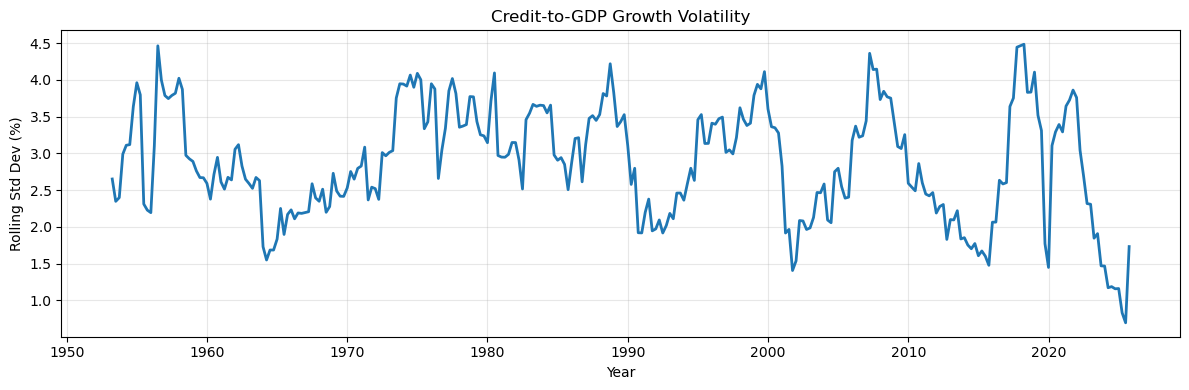

In [73]:
# ----------------------------------------------------
# Plot Rolling Volatility
# ----------------------------------------------------

plt.figure(figsize=(12,4))

plt.plot(
    df_credit_gdp["Date"],
    df_credit_gdp["Rolling Volatility"],
    linewidth=2
)

plt.title("Credit-to-GDP Growth Volatility")
plt.xlabel("Year")
plt.ylabel("Rolling Std Dev (%)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [74]:
# ----------------------------------------------------
# Four-Quarter Moving Average
# ----------------------------------------------------

df_credit_gdp["4Q Moving Average"] = (
    df_credit_gdp["OBS_VALUE"]
    .rolling(4)
    .mean()
)

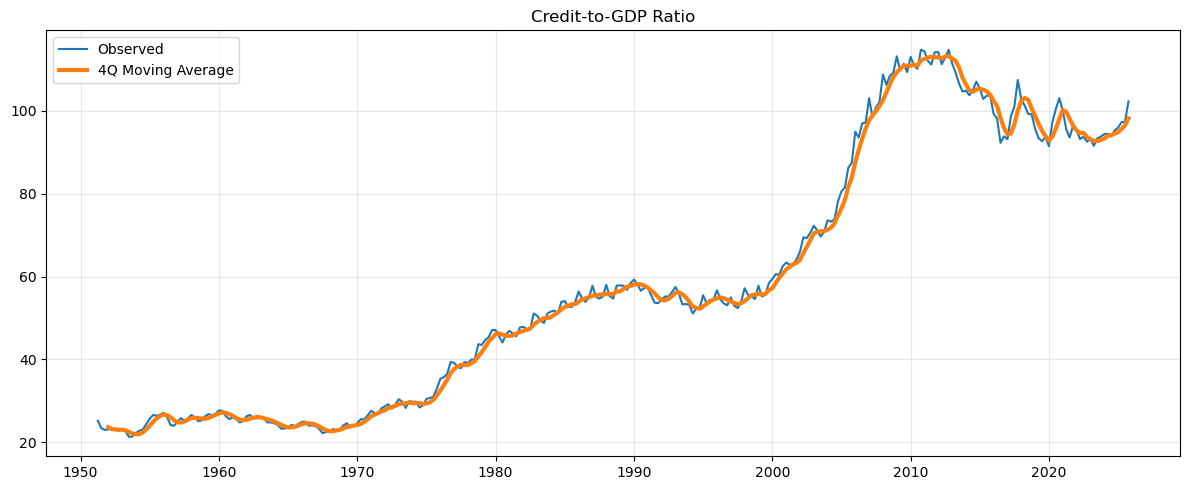

In [75]:
# ----------------------------------------------------
# Trend Analysis
# ----------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    df_credit_gdp["Date"],
    df_credit_gdp["OBS_VALUE"],
    label="Observed"
)

plt.plot(
    df_credit_gdp["Date"],
    df_credit_gdp["4Q Moving Average"],
    linewidth=3,
    label="4Q Moving Average"
)

plt.legend()

plt.title("Credit-to-GDP Ratio")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [76]:
# ----------------------------------------------------
# Latest Observation
# ----------------------------------------------------

latest = df_credit_gdp.iloc[-1]

snapshot = pd.DataFrame({

    "Metric": [
        "Latest Quarter",
        "Credit-to-GDP (%)",
        "QoQ Growth (%)",
        "YoY Growth (%)"
    ],

    "Value": [
        latest["TIME_PERIOD"],
        latest["OBS_VALUE"],
        latest["QoQ_Growth (%)"],
        latest["YoY_Growth (%)"]
    ]

})

snapshot

,Metric,Value
0,Latest Quarter,2025-Q4
1,Credit-to-GDP (%),102.3
2,QoQ Growth (%),5.030801
3,YoY Growth (%),7.345226


In [77]:
# ----------------------------------------------------
# Historical Rank
# ----------------------------------------------------

rank = (
    df_credit_gdp["OBS_VALUE"]
    .rank(method="min", ascending=False)
    .iloc[-1]
)

total = len(df_credit_gdp)

print(f"Historical Rank : {int(rank)} out of {total}")

Historical Rank : 37 out of 299


In [78]:
# ----------------------------------------------------
# Highest Credit-to-GDP Ratios
# ----------------------------------------------------

(
    df_credit_gdp
    .nlargest(
        10,
        "OBS_VALUE"
    )[
        [
            "TIME_PERIOD",
            "OBS_VALUE"
        ]
    ]
)

,TIME_PERIOD,OBS_VALUE
238,2010-Q4,114.8
246,2012-Q4,114.8
239,2011-Q1,114.4
242,2011-Q4,114.2
243,2012-Q1,114.2
231,2009-Q1,113.2
235,2010-Q1,113.1
245,2012-Q3,112.9
240,2011-Q2,112.1
247,2013-Q1,111.5


In [79]:
# ----------------------------------------------------
# Lowest Credit-to-GDP Ratios
# ----------------------------------------------------

(
    df_credit_gdp
    .nsmallest(
        10,
        "OBS_VALUE"
    )[
        [
            "TIME_PERIOD",
            "OBS_VALUE"
        ]
    ]
)

,TIME_PERIOD,OBS_VALUE
9,1953-Q3,21.3
10,1953-Q4,21.4
65,1967-Q3,22.2
11,1954-Q1,22.3
66,1967-Q4,22.5
8,1953-Q2,22.7
6,1952-Q4,22.8
12,1954-Q2,22.8
67,1968-Q1,22.8
69,1968-Q3,22.9


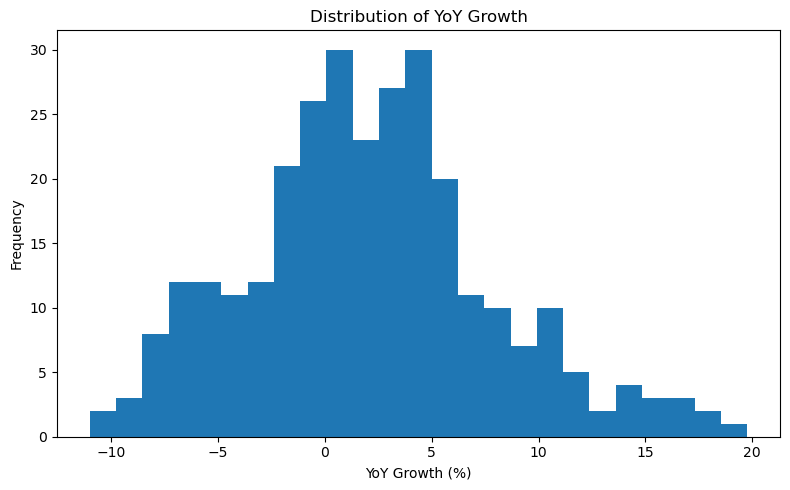

In [80]:
# ----------------------------------------------------
# Distribution of YoY Growth
# ----------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_credit_gdp["YoY_Growth (%)"].dropna(),
    bins=25
)

plt.title("Distribution of YoY Growth")

plt.xlabel("YoY Growth (%)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [81]:
# ----------------------------------------------------
# Historical Percentile
# ----------------------------------------------------

percentile = (
    df_credit_gdp["OBS_VALUE"]
    .rank(pct=True)
    .iloc[-1]
)

print(f"Current observation is higher than {percentile:.1%} of historical observations.")

Current observation is higher than 88.0% of historical observations.


In [82]:
# ----------------------------------------------------
# Standardized Credit-to-GDP
# ----------------------------------------------------

mean = df_credit_gdp["OBS_VALUE"].mean()

std = df_credit_gdp["OBS_VALUE"].std()

df_credit_gdp["Z_SCORE"] = (
    df_credit_gdp["OBS_VALUE"] - mean
) / std

In [83]:
# ----------------------------------------------------
# Latest Z-Score
# ----------------------------------------------------

df_credit_gdp[
    [
        "TIME_PERIOD",
        "OBS_VALUE",
        "Z_SCORE"
    ]
].tail()

,TIME_PERIOD,OBS_VALUE,Z_SCORE
294,2024-Q4,95.3,1.232041
295,2025-Q1,96.0,1.255079
296,2025-Q2,97.3,1.297863
297,2025-Q3,97.4,1.301154
298,2025-Q4,102.3,1.462418


In [84]:
# ----------------------------------------------------
# Long-Term Trend
# ----------------------------------------------------

df_credit_gdp["8Q Moving Average"] = (
    df_credit_gdp["OBS_VALUE"]
    .rolling(8)
    .mean()
)

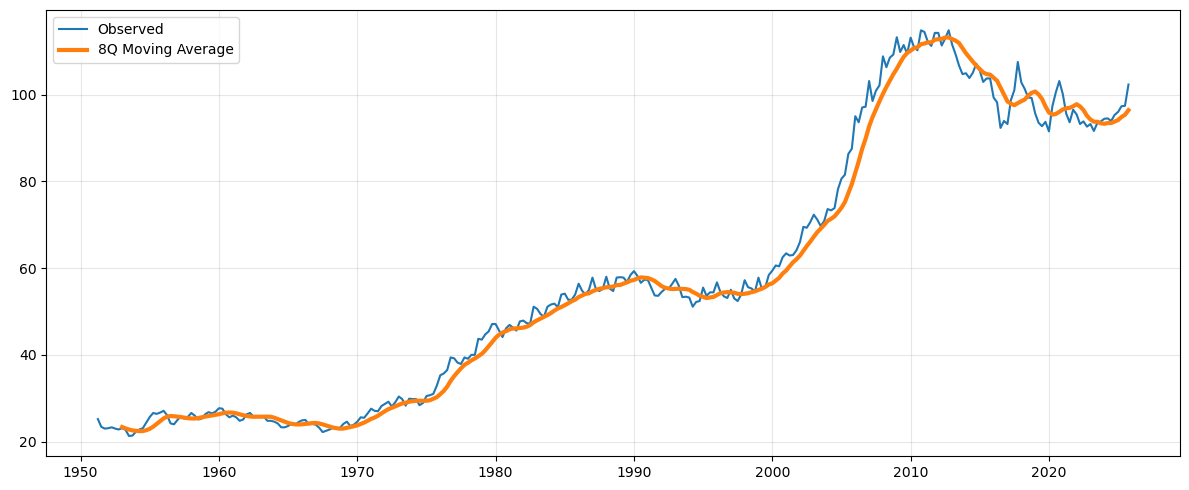

In [85]:
# ----------------------------------------------------
# Long-Term Trend
# ----------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    df_credit_gdp["Date"],
    df_credit_gdp["OBS_VALUE"],
    label="Observed"
)

plt.plot(
    df_credit_gdp["Date"],
    df_credit_gdp["8Q Moving Average"],
    linewidth=3,
    label="8Q Moving Average"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [90]:
# ----------------------------------------------------
# Economic Summary
# ----------------------------------------------------

summary = pd.DataFrame({

    "Metric": [
        "Latest Quarter",
        "Latest Credit-to-GDP",
        "Historical Average",
        "Historical Maximum",
        "Historical Minimum",
        "Current Percentile",
        "Current Z-Score"
    ],

    "Value": [

        df_credit_gdp.iloc[-1]["TIME_PERIOD"],

        round(df_credit_gdp.iloc[-1]["OBS_VALUE"], 2),

        round(df_credit_gdp["OBS_VALUE"].mean(), 2),

        round(df_credit_gdp["OBS_VALUE"].max(), 2),

        round(df_credit_gdp["OBS_VALUE"].min(), 2),

        f"{percentile:.1%}",

        round(df_credit_gdp.iloc[-1]["Z_SCORE"], 2)

    ]

})

summary

,Metric,Value
0,Latest Quarter,2025-Q4
1,Latest Credit-to-GDP,102.3
2,Historical Average,57.86
3,Historical Maximum,114.8
4,Historical Minimum,21.3
5,Current Percentile,88.0%
6,Current Z-Score,1.46


# Conclusion

In this notebook, we completed the transition from SDMX data retrieval to macroeconomic time-series analysis.

Starting from the BIS SDMX API, we successfully:

- Retrieved and explored the BIS Total Credit dataset.
- Converted SDMX observations into a structured pandas DataFrame.
- Used SDMX codelists to replace coded values with descriptive labels.
- Built an analysis-ready dataset with appropriate data types.
- Engineered commonly used macroeconomic indicators, including QoQ growth, YoY growth, moving averages, rolling volatility, and standardized (Z-score) measures.
- Explored long-term trends, historical rankings, growth distributions, and recent economic conditions.

The resulting workflow mirrors the early stages of a real-world economic analysis pipeline, where analysts first acquire, validate, prepare, and understand the data before applying statistical or predictive models.

### Key Takeaways

- SDMX is more than a data format—it provides rich metadata that makes datasets self-describing.
- Understanding the underlying data structure is essential before performing any analysis.
- Time-series feature engineering is a critical step between raw data acquisition and quantitative modeling.
- Economic interpretation should accompany every analytical result rather than relying solely on statistical summaries.

The next notebook will build on this foundation by introducing more advanced time-series techniques and comparative analyses while continuing to work with official BIS SDMX datasets.